In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, '.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from imblearn.over_sampling  import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine        import SMOTETomek

from sqlalchemy import text
from scripts.database import engine

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
os.makedirs('data/graficas', exist_ok=True)

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")

2026-05-15 00:36:33.622 
  command:

    streamlit run /usr/local/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]


✅ Librerías importadas correctamente
   pandas   2.2.3
   numpy    1.26.4
   seaborn  0.13.2


In [2]:
# ── CELDA 2: Extracción SQL ───────────────────────────────────────────────────
# Se eliminó 'rank' — data leakage (rank derivado directamente del score).
# Se añaden type, status, year, genres para enriquecer el modelo.

SQL_QUERY = """
SELECT
    popularity,
    favorites,
    episodes,
    year,
    type,
    status,
    genres,
    CASE
        WHEN score >= 8.5 THEN 1
        ELSE 0
    END AS es_top_tier
FROM anime
WHERE score      IS NOT NULL
  AND popularity IS NOT NULL
  AND favorites  IS NOT NULL
  AND episodes   IS NOT NULL
  AND type       IS NOT NULL
  AND status     IS NOT NULL
ORDER BY mal_id
"""

with engine.connect() as conn:
    df_anime = pd.read_sql(text(SQL_QUERY), conn)

print(f"✅ Datos cargados: {df_anime.shape[0]:,} filas × {df_anime.shape[1]} columnas")
print(f"\nColumnas disponibles:\n{df_anime.columns.tolist()}")
print(f"\nBalance de la variable objetivo:")
bal = df_anime['es_top_tier'].value_counts()
pct = df_anime['es_top_tier'].value_counts(normalize=True) * 100
print(f"   Top Tier (score ≥ 8.5) [1]: {bal[1]:,}  ({pct[1]:.1f}%)")
print(f"   Resto   (score < 8.5) [0]: {bal[0]:,}  ({pct[0]:.1f}%)")
print(f"\nValores únicos por columna categórica:")
print(f"   type   : {df_anime['type'].unique()}")
print(f"   status : {df_anime['status'].unique()}")
df_anime.head()

✅ Datos cargados: 492 filas × 8 columnas

Columnas disponibles:
['popularity', 'favorites', 'episodes', 'year', 'type', 'status', 'genres', 'es_top_tier']

Balance de la variable objetivo:
   Top Tier (score ≥ 8.5) [1]: 166  (33.7%)
   Resto   (score < 8.5) [0]: 326  (66.3%)

Valores únicos por columna categórica:
   type   : ['TV' 'Movie' 'OVA' 'TV Special' 'Special' 'Music' 'ONA' 'PV']
   status : ['Finished Airing' 'Currently Airing']


,popularity,favorites,episodes,year,type,status,genres,es_top_tier
0,42,89077,26,1998.0,TV,Finished Airing,"Action, Award Winning, Sci-Fi",1
1,654,1772,1,NaN,Movie,Finished Airing,"Action, Sci-Fi",0
2,264,17483,26,1998.0,TV,Finished Airing,"Action, Adventure, Sci-Fi",0
3,1300,1422,24,2004.0,TV,Finished Airing,"Action, Drama",0
4,119,61294,74,2004.0,TV,Finished Airing,"Drama, Mystery, Suspense",1


In [3]:
# ── CELDA 3: Validación y Exploración ────────────────────────────────────────
print("=" * 55)
print("VALIDACIÓN DEL DATASET")
print("=" * 55)
print("\n📋 Tipos de datos y valores nulos:")
print(df_anime.dtypes.to_frame('dtype').join(df_anime.isnull().sum().to_frame('nulos')))

balance = df_anime['es_top_tier'].value_counts()
pct     = df_anime['es_top_tier'].value_counts(normalize=True) * 100
print(f"\n🎯 Balance de la variable objetivo:")
print(f"   Top Tier (score ≥ 8.5) [1]: {balance[1]:>5,}  ({pct[1]:.1f}%)")
print(f"   Resto   (score < 8.5) [0]: {balance[0]:>5,}  ({pct[0]:.1f}%)")

print(f"\n📊 Estadísticas numéricas por clase:")
print(df_anime.groupby('es_top_tier')[['favorites', 'popularity', 'episodes']].mean().round(1))

VALIDACIÓN DEL DATASET

📋 Tipos de datos y valores nulos:
               dtype  nulos
popularity     int64      0
favorites      int64      0
episodes       int64      0
year         float64    198
type          object      0
status        object      0
genres        object      0
es_top_tier    int64      0

🎯 Balance de la variable objetivo:
   Top Tier (score ≥ 8.5) [1]:   166  (33.7%)
   Resto   (score < 8.5) [0]:   326  (66.3%)

📊 Estadísticas numéricas por clase:
             favorites  popularity  episodes
es_top_tier                                 
0               8529.8      1724.4      18.7
1              23236.7      1066.1      17.7


In [4]:
# ── CELDA 4: Preprocesamiento — Sin rank, Con encoding categórico ─────────────
df = df_anime.copy()

# 4.1 Extraer géneros como features binarias
top_generos = ['Action', 'Drama', 'Comedy', 'Romance', 'Fantasy',
               'Sci-Fi', 'Slice of Life', 'Mystery', 'Thriller', 'Sports']
for g in top_generos:
    df[f'genero_{g.replace(" ", "_")}'] = df['genres'].fillna('').str.contains(g, case=False).astype(int)

# 4.2 One-Hot Encoding para variables categóricas
df = pd.get_dummies(df, columns=['type'], drop_first=True, dtype=int)
df = pd.get_dummies(df, columns=['status'], drop_first=True, dtype=int)

# 4.3 Año: rellenar nulos con mediana
df['year'] = df['year'].fillna(df['year'].median()).astype(int)

# 4.4 Definir X e y
drop_cols = ['es_top_tier', 'genres']
X_df = df.drop(columns=drop_cols).astype(float)
y    = df['es_top_tier'].values

FEATURES   = X_df.columns.tolist()
SCALE_COLS = ['popularity', 'favorites', 'episodes', 'year']

# 4.5 StandardScaler — OBLIGATORIO para Regresión Logística
# (el árbol CART NO necesita este paso)
scaler   = StandardScaler()
X_scaled = X_df.copy()
X_scaled[SCALE_COLS] = scaler.fit_transform(X_df[SCALE_COLS])
X_arr    = X_scaled.values

print(f"✅ Preprocesamiento completado")
print(f"   Shape X: {X_arr.shape}")
print(f"   Features numéricas escaladas: {SCALE_COLS}")
print(f"   Features categóricas (OHE):   {[f for f in FEATURES if f not in SCALE_COLS]}")
print(f"\n   Media tras escalar (cols numéricas): {X_scaled[SCALE_COLS].mean().round(4).values} (≈ 0)")
print(f"   Std  tras escalar (cols numéricas): {X_scaled[SCALE_COLS].std().round(4).values}  (≈ 1)")
print(f"\n   Clases en y → 0: {(y==0).sum():,}  |  1: {(y==1).sum():,}")
print("\n⚠️  El árbol CART NO necesita StandardScaler. La Regresión Logística SÍ.")

✅ Preprocesamiento completado
   Shape X: (492, 22)
   Features numéricas escaladas: ['popularity', 'favorites', 'episodes', 'year']
   Features categóricas (OHE):   ['genero_Action', 'genero_Drama', 'genero_Comedy', 'genero_Romance', 'genero_Fantasy', 'genero_Sci-Fi', 'genero_Slice_of_Life', 'genero_Mystery', 'genero_Thriller', 'genero_Sports', 'type_Music', 'type_ONA', 'type_OVA', 'type_PV', 'type_Special', 'type_TV', 'type_TV Special', 'status_Finished Airing']

   Media tras escalar (cols numéricas): [ 0. -0. -0. -0.] (≈ 0)
   Std  tras escalar (cols numéricas): [1.001 1.001 1.001 1.001]  (≈ 1)

   Clases en y → 0: 326  |  1: 166

⚠️  El árbol CART NO necesita StandardScaler. La Regresión Logística SÍ.


In [5]:
# ── CELDA 5: Función de entrenamiento + evaluación ───────────────────────────
COLORS = {'original': '#2a5298', 'oversample': '#27ae60',
          'undersample': '#e74c3c', 'hybrid': '#f39c12'}

def entrenar_evaluar_logit(X_tr, X_te, y_tr, y_te, nombre, color='#2a5298'):
    """
    Entrena LogisticRegression y devuelve dict con modelo + métricas.

    Parámetros clave:
      · class_weight='balanced' — peso automático para compensar desbalance
      · max_iter=1000           — suficientes iteraciones para convergencia
      · stratify en el split    — se aplica antes de llamar esta función
    """
    modelo = LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    )
    modelo.fit(X_tr, y_tr)

    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_prob)

    return {
        'nombre'    : nombre,
        'modelo'    : modelo,
        'color'     : color,
        'accuracy'  : accuracy_score(y_te, y_pred),
        'precision' : precision_score(y_te, y_pred, zero_division=0),
        'recall'    : recall_score(y_te, y_pred, zero_division=0),
        'f1'        : f1_score(y_te, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_te, y_prob),
        'fpr'       : fpr, 'tpr': tpr,
        'y_test'    : y_te, 'y_pred': y_pred,
        'train_size': len(X_tr), 'test_size': len(X_te),
        'dist_train': f"0:{(y_tr==0).sum()} / 1:{(y_tr==1).sum()}",
    }

print("✅ Función `entrenar_evaluar_logit` definida")
print("   · class_weight='balanced' — compensa desbalance de clases")
print("   · max_iter=1000")

✅ Función `entrenar_evaluar_logit` definida
   · class_weight='balanced' — compensa desbalance de clases
   · max_iter=1000


In [6]:
# ── CELDA 6: Split 80/20 + Oversampling + Undersampling + Hybrid ──────────────
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_arr, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Split base 80/20:")
print(f"  Train: {len(X_train_raw):,}  (0:{(y_train_raw==0).sum()} / 1:{(y_train_raw==1).sum()})")
print(f"  Test : {len(X_test):,}   (0:{(y_test==0).sum()} / 1:{(y_test==1).sum()})")

# ── 1. Sin muestreo ────────────────────────────────────────────────────────────
print("\n[1/4] Entrenando con datos ORIGINALES...")
res_original = entrenar_evaluar_logit(
    X_train_raw, X_test, y_train_raw, y_test,
    nombre='Original (sin muestreo)', color=COLORS['original']
)

# ── 2. Oversampling — SMOTE ────────────────────────────────────────────────────
print("[2/4] Aplicando SMOTE (Oversampling)...")
smote = SMOTE(random_state=42)
X_over, y_over = smote.fit_resample(X_train_raw, y_train_raw)
print(f"       Train tras SMOTE: {len(X_over):,}  (0:{(y_over==0).sum()} / 1:{(y_over==1).sum()})")
res_over = entrenar_evaluar_logit(
    X_over, X_test, y_over, y_test,
    nombre='Oversampling (SMOTE)', color=COLORS['oversample']
)

# ── 3. Undersampling — RandomUnderSampler ─────────────────────────────────────
print("[3/4] Aplicando RandomUnderSampler (Undersampling)...")
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train_raw, y_train_raw)
print(f"       Train tras RUS  : {len(X_under):,}  (0:{(y_under==0).sum()} / 1:{(y_under==1).sum()})")
res_under = entrenar_evaluar_logit(
    X_under, X_test, y_under, y_test,
    nombre='Undersampling (RUS)', color=COLORS['undersample']
)

# ── 4. Hybrid — SMOTETomek ────────────────────────────────────────────────────
print("[4/4] Aplicando SMOTETomek (Hybrid)...")
smt = SMOTETomek(random_state=42)
X_hybrid, y_hybrid = smt.fit_resample(X_train_raw, y_train_raw)
print(f"       Train tras SMOTETomek: {len(X_hybrid):,}  (0:{(y_hybrid==0).sum()} / 1:{(y_hybrid==1).sum()})")
res_hybrid = entrenar_evaluar_logit(
    X_hybrid, X_test, y_hybrid, y_test,
    nombre='Hybrid (SMOTETomek)', color=COLORS['hybrid']
)

resultados = [res_original, res_over, res_under, res_hybrid]
print("\n✅ Los 4 modelos entrenados correctamente")

Split base 80/20:
  Train: 393  (0:260 / 1:133)
  Test : 99   (0:66 / 1:33)

[1/4] Entrenando con datos ORIGINALES...
[2/4] Aplicando SMOTE (Oversampling)...
       Train tras SMOTE: 520  (0:260 / 1:260)
[3/4] Aplicando RandomUnderSampler (Undersampling)...
       Train tras RUS  : 266  (0:133 / 1:133)
[4/4] Aplicando SMOTETomek (Hybrid)...
       Train tras SMOTETomek: 474  (0:237 / 1:237)

✅ Los 4 modelos entrenados correctamente


In [7]:
# ── CELDA 7: Métricas comparativas ───────────────────────────────────────────
print("=" * 78)
print(f"{'MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA (Top Tier Anime)':^78}")
print("=" * 78)
header = f"{'Técnica':<28} {'Train':>8} {'Test':>6} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 78)
for r in resultados:
    print(
        f"{r['nombre']:<28} {r['train_size']:>8,} {r['test_size']:>6,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )
print("=" * 78)

         MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA (Top Tier Anime)         
Técnica                         Train   Test     Acc    Prec  Recall      F1     AUC
------------------------------------------------------------------------------
Original (sin muestreo)           393     99  0.7071  0.5556  0.6061  0.5797  0.7071
Oversampling (SMOTE)              520     99  0.7071  0.5476  0.6970  0.6133  0.7016
Undersampling (RUS)               266     99  0.6465  0.4750  0.5758  0.5205  0.6713
Hybrid (SMOTETomek)               474     99  0.6970  0.5366  0.6667  0.5946  0.6988


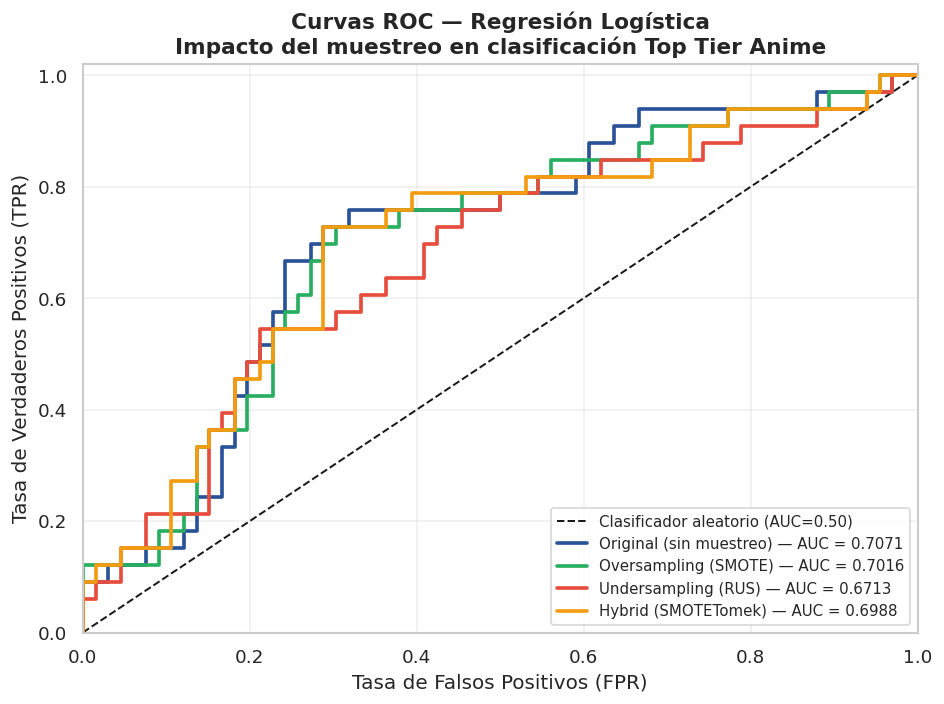

💾 Guardado: data/graficas/logit_roc_muestreo.png


In [8]:
# ── CELDA 8: Curvas ROC — los 4 métodos superpuestos ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio (AUC=0.50)')

for r in resultados:
    ax.plot(r['fpr'], r['tpr'], color=r['color'], lw=2.2,
            label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}")

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Regresión Logística\nImpacto del muestreo en clasificación Top Tier Anime',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('data/graficas/logit_roc_muestreo.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardado: data/graficas/logit_roc_muestreo.png")

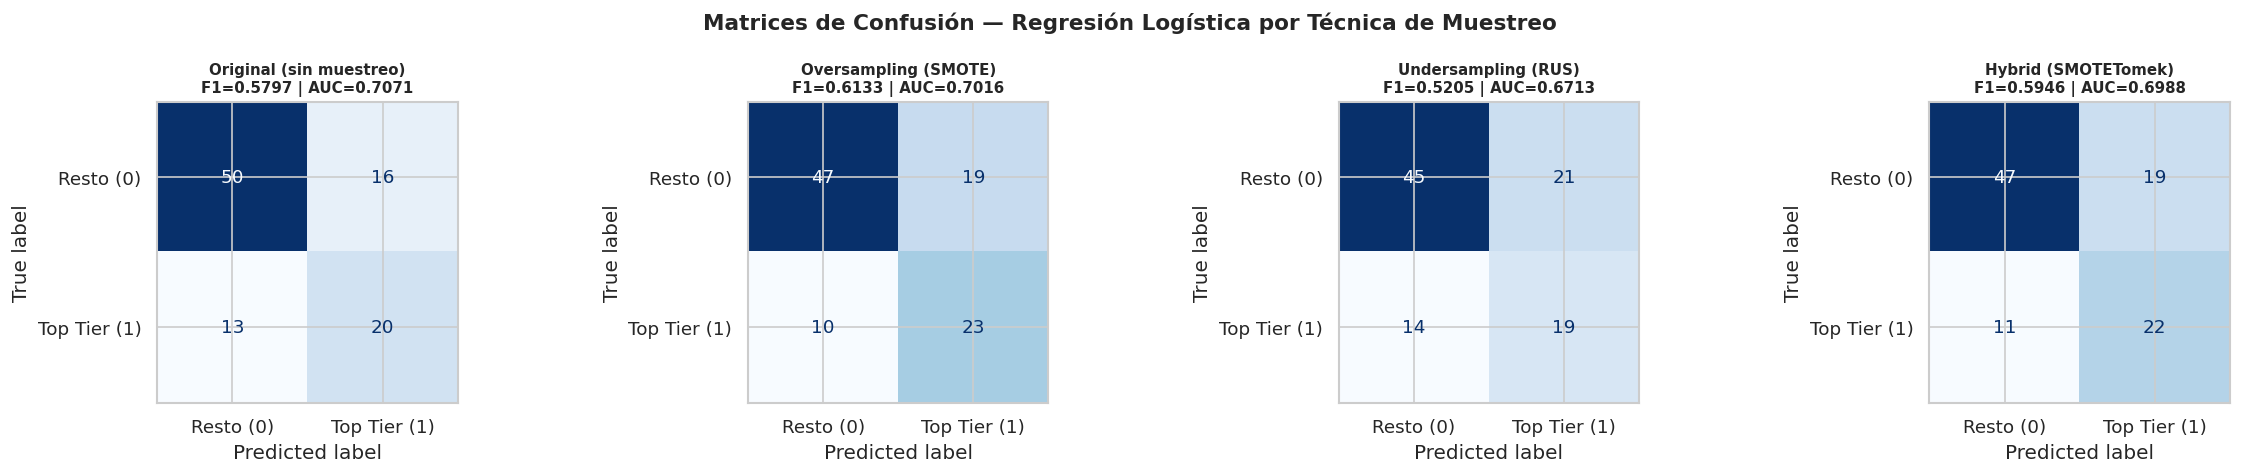

💾 Guardado: data/graficas/logit_confusion_muestreo.png


In [9]:
# ── CELDA 9: Matrices de Confusión — los 4 métodos ───────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Matrices de Confusión — Regresión Logística por Técnica de Muestreo',
             fontsize=13, fontweight='bold')

for ax, r in zip(axes, resultados):
    cm   = confusion_matrix(r['y_test'], r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Resto (0)', 'Top Tier (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['nombre']}\nF1={r['f1']:.4f} | AUC={r['roc_auc']:.4f}",
                 fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('data/graficas/logit_confusion_muestreo.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardado: data/graficas/logit_confusion_muestreo.png")

Modelo de referencia: Oversampling (SMOTE)


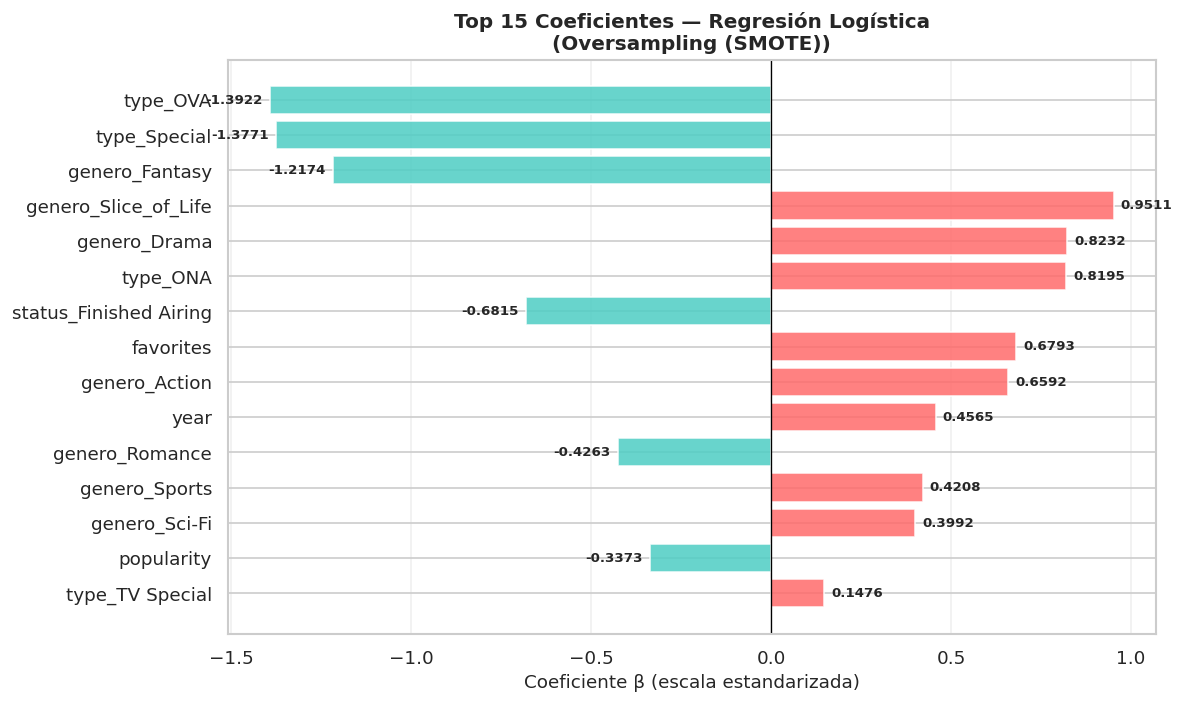


📊 Intercepto (β₀): 0.1076

Top 10 variables más influyentes:
               Feature  Coeficiente  Odds Ratio
              type_OVA    -1.392219    0.248523
          type_Special    -1.377074    0.252316
        genero_Fantasy    -1.217438    0.295987
  genero_Slice_of_Life     0.951078    2.588498
          genero_Drama     0.823163    2.277694
              type_ONA     0.819454    2.269260
status_Finished Airing    -0.681459    0.505879
             favorites     0.679310    1.972517
         genero_Action     0.659228    1.933300
                  year     0.456538    1.578600


In [10]:
# ── CELDA 10: Coeficientes del modelo logístico ───────────────────────────────
mejor_f1 = max(resultados, key=lambda r: r['f1'])
print(f"Modelo de referencia: {mejor_f1['nombre']}")

coefs = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coeficiente': mejor_f1['modelo'].coef_[0],
    'Odds Ratio' : np.exp(mejor_f1['modelo'].coef_[0])
}).sort_values('Coeficiente', ascending=True)

# Top 15 por valor absoluto
top_coefs = coefs.reindex(coefs['Coeficiente'].abs().sort_values(ascending=True).index).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
colores_c = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in top_coefs['Coeficiente']]
bars = ax.barh(top_coefs['Feature'], top_coefs['Coeficiente'],
               color=colores_c, alpha=0.85, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente β (escala estandarizada)', fontsize=11)
ax.set_title(f'Top 15 Coeficientes — Regresión Logística\n({mejor_f1["nombre"]})',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for patch in ax.patches:
    w = patch.get_width()
    if abs(w) > 0.01:
        ax.text(w + (0.02 if w >= 0 else -0.02),
                patch.get_y() + patch.get_height()/2,
                f'{w:.4f}', va='center',
                ha='left' if w >= 0 else 'right',
                fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('data/graficas/logit_coeficientes_muestreo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Intercepto (β₀): {mejor_f1['modelo'].intercept_[0]:.4f}")
print(f"\nTop 10 variables más influyentes:")
print(coefs.reindex(coefs['Coeficiente'].abs().sort_values(ascending=False).index).head(10)[
    ['Feature', 'Coeficiente', 'Odds Ratio']].to_string(index=False))

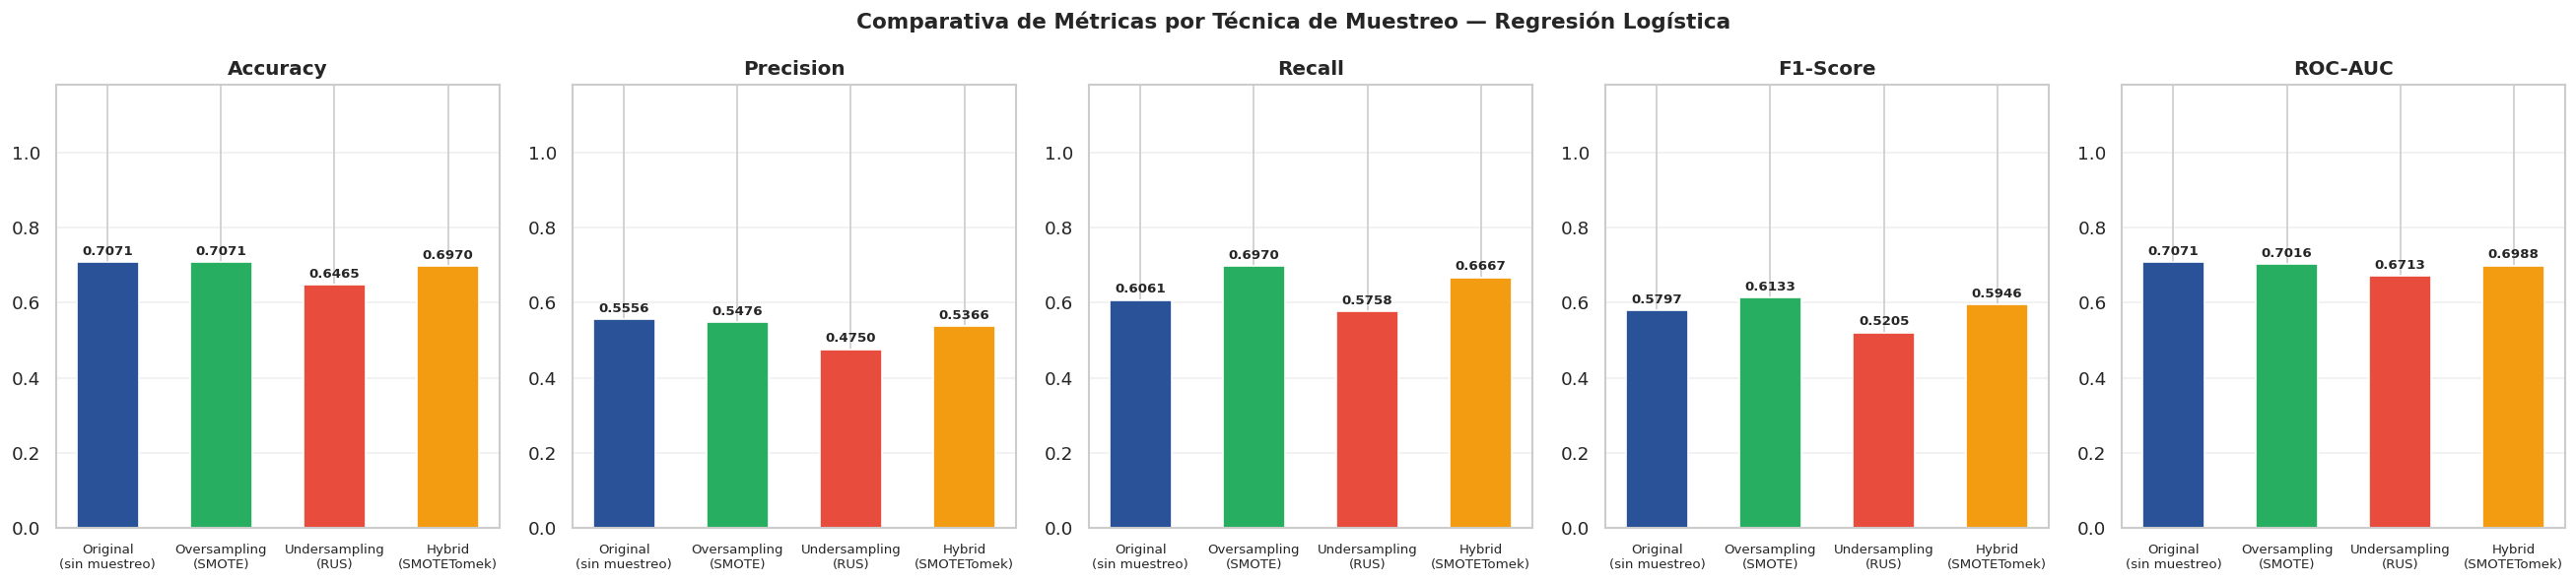

💾 Guardado: data/graficas/logit_comparativa_muestreo.png


In [11]:
# ── CELDA 11: Gráfica comparativa de métricas ────────────────────────────────
metricas_keys   = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metricas_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

fig, axes = plt.subplots(1, len(metricas_keys), figsize=(22, 5))
fig.suptitle('Comparativa de Métricas por Técnica de Muestreo — Regresión Logística',
             fontsize=13, fontweight='bold')

nombres = [r['nombre'].replace(' (', '\n(') for r in resultados]
colores = [r['color'] for r in resultados]

for ax, key, label in zip(axes, metricas_keys, metricas_labels):
    vals = [r[key] for r in resultados]
    ax.bar(nombres, vals, color=colores, edgecolor='white', width=0.55)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.18)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('data/graficas/logit_comparativa_muestreo.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardado: data/graficas/logit_comparativa_muestreo.png")

In [12]:
# ── CELDA 12: Tabla final con gradiente de color ─────────────────────────────
resumen = pd.DataFrame([{
    'Técnica'      : r['nombre'],
    'N Train'      : r['train_size'],
    'N Test'       : r['test_size'],
    'Dist. Train'  : r['dist_train'],
    'Accuracy'     : round(r['accuracy'],  4),
    'Precision'    : round(r['precision'], 4),
    'Recall'       : round(r['recall'],    4),
    'F1-Score'     : round(r['f1'],        4),
    'ROC-AUC'      : round(r['roc_auc'],   4),
} for r in resultados]).set_index('Técnica')

print("=" * 65)
print(f"{'TABLA FINAL DE MÉTRICAS — REGRESIÓN LOGÍSTICA':^65}")
print("=" * 65)
display(
    resumen.style
    .background_gradient(cmap='Greens',
        subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .format('{:.4f}',
        subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .set_caption("Regresión Logística — Clasificación Top Tier Anime · Impacto del muestreo")
)

mejor_f1  = resumen['F1-Score'].idxmax()
mejor_auc = resumen['ROC-AUC'].idxmax()
acc_rango = resumen['Accuracy'].max() - resumen['Accuracy'].min()

print(f"\n1. ESTABILIDAD DEL MODELO")
print(f"   Rango Accuracy entre técnicas: {acc_rango:.4f}")
if acc_rango < 0.05:
    print("   ✅ Modelo estable entre técnicas de muestreo")
else:
    print("   ⚠️  El muestreo impacta significativamente las métricas")

print(f"\n2. MEJOR TÉCNICA (por F1-Score): {mejor_f1}")
print(f"   F1={resumen.loc[mejor_f1,'F1-Score']:.4f}  AUC={resumen.loc[mejor_f1,'ROC-AUC']:.4f}")
print(f"\n3. MEJOR TÉCNICA (por AUC):      {mejor_auc}")
print(f"   AUC={resumen.loc[mejor_auc,'ROC-AUC']:.4f}  F1={resumen.loc[mejor_auc,'F1-Score']:.4f}")

print("""
4. INTERPRETACIÓN DEL MUESTREO
   · Original       → baseline sin ajuste. Puede tener Recall bajo en clase minoritaria.
   · SMOTE          → genera ejemplos sintéticos de Top Tier interpolando en el espacio
                       de features. Mejora el Recall pero puede reducir la Precision.
   · RandomUnderSampler → elimina aleatoriamente ejemplos de Resto hasta igualar clases.
                           Pierde información de la clase mayoritaria.
   · SMOTETomek (Hybrid) → SMOTE + eliminación de puntos en la frontera de decisión
                            (Tomek Links). Balance entre Precision y Recall.

5. ¿POR QUÉ SE ELIMINÓ 'rank'?
   rank está ordenado directamente por score. Es data leakage: el modelo aprendería
   de información derivada de la variable que queremos predecir.

6. NUEVAS VARIABLES INCLUIDAS
   · type    → One-Hot Encoding (TV, Movie, OVA, Special...)
   · status  → One-Hot Encoding (Finished Airing, Currently Airing...)
   · year    → Año de estreno (tendencias temporales)
   · géneros → Binarias por género (Action, Drama, Comedy, Romance...)
""")

          TABLA FINAL DE MÉTRICAS — REGRESIÓN LOGÍSTICA          


,N Train,N Test,Dist. Train,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Técnica,,,,,,,,
Original (sin muestreo),393,99,0:260 / 1:133,0.7071,0.5556,0.6061,0.5797,0.7071
Oversampling (SMOTE),520,99,0:260 / 1:260,0.7071,0.5476,0.6970,0.6133,0.7016
Undersampling (RUS),266,99,0:133 / 1:133,0.6465,0.4750,0.5758,0.5205,0.6713
Hybrid (SMOTETomek),474,99,0:237 / 1:237,0.6970,0.5366,0.6667,0.5946,0.6988



1. ESTABILIDAD DEL MODELO
   Rango Accuracy entre técnicas: 0.0606
   ⚠️  El muestreo impacta significativamente las métricas

2. MEJOR TÉCNICA (por F1-Score): Oversampling (SMOTE)
   F1=0.6133  AUC=0.7016

3. MEJOR TÉCNICA (por AUC):      Original (sin muestreo)
   AUC=0.7071  F1=0.5797

4. INTERPRETACIÓN DEL MUESTREO
   · Original       → baseline sin ajuste. Puede tener Recall bajo en clase minoritaria.
   · SMOTE          → genera ejemplos sintéticos de Top Tier interpolando en el espacio
                       de features. Mejora el Recall pero puede reducir la Precision.
   · RandomUnderSampler → elimina aleatoriamente ejemplos de Resto hasta igualar clases.
                           Pierde información de la clase mayoritaria.
   · SMOTETomek (Hybrid) → SMOTE + eliminación de puntos en la frontera de decisión
                            (Tomek Links). Balance entre Precision y Recall.

5. ¿POR QUÉ SE ELIMINÓ 'rank'?
   rank está ordenado directamente por score. Es data leakage: